# Single-Cell NicheNet's Ligand Activity Analysis

This notebook shows how NicheNet can predict which ligands might be active in single cells. If a ligand has a high activity in a cell, this means that target genes of that ligand are more strongly expressed in that cell than in other cells.

We use data from Puram et al. (2017) to explore intercellular communication in the tumor microenvironment of HNSCC. We assess the activity of cancer-associated fibroblast (CAF) ligands in malignant cells.

To prioritize ligands regulating a process of interest, we perform a correlation analysis between ligand activities in cells and cell-level scores corresponding to the process (p-EMT in this case).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nichenetr as nn

### Read in expression data of interacting cells

In [2]:
hnscc_data = nn.load_hnscc_expression()
expression = hnscc_data["expression"]
sample_info = hnscc_data["sample_info"]

expression_df = pd.DataFrame(
    expression.data.toarray(),
    index=expression.rownames,
    columns=expression.colnames,
)

In [3]:
# Determine expressed genes in CAFs and malignant cells
tumors_remove = ["HN10", "HN", "HN12", "HN13", "HN24", "HN7", "HN8", "HN23"]

CAF_ids = sample_info[
    (sample_info["Lymph node"] == 0)
    & (~sample_info["tumor"].isin(tumors_remove))
    & (sample_info["non-cancer cell type"] == "CAF")
]["cell"].tolist()

malignant_ids = sample_info[
    (sample_info["Lymph node"] == 0)
    & (~sample_info["tumor"].isin(tumors_remove))
    & (sample_info["classified  as cancer cell"] == 1)
]["cell"].tolist()

def get_expressed_custom(expression_df, cell_ids):
    sub = expression_df.loc[expression_df.index.isin(cell_ids)]
    tpm = 10 * (2 ** sub - 1)
    agg = np.log2(tpm.mean(axis=0) + 1)
    return agg[agg >= 4].index.tolist()

expressed_genes_CAFs = get_expressed_custom(expression_df, CAF_ids)
expressed_genes_malignant = get_expressed_custom(expression_df, malignant_ids)
print(f"Expressed genes in CAFs: {len(expressed_genes_CAFs)}")
print(f"Expressed genes in malignant cells: {len(expressed_genes_malignant)}")

Expressed genes in CAFs: 6706
Expressed genes in malignant cells: 6351


### Load the ligand-target model and define potential ligands

In [4]:
ligand_target_matrix = nn.load_ligand_target_matrix("human")
lr_network = nn.load_lr_network("human")

ligands = lr_network["from"].unique().tolist()
expressed_ligands = list(set(ligands) & set(expressed_genes_CAFs))

receptors = lr_network["to"].unique().tolist()
expressed_receptors = list(set(receptors) & set(expressed_genes_malignant))

potential_ligands = (
    lr_network[
        lr_network["from"].isin(expressed_ligands)
        & lr_network["to"].isin(expressed_receptors)
    ]["from"].unique().tolist()
)
print(f"Potential ligands: {len(potential_ligands)}")

Potential ligands: 203


### Perform single-cell ligand activity analysis

Scale the expression data and run the analysis on 10 example cells from HN5 tumor.

In [5]:
background_expressed_genes = [
    g for g in expressed_genes_malignant if g in ligand_target_matrix.rownames
]

expression_scaled = nn.scale_quantile(
    expression_df.loc[expression_df.index.isin(malignant_ids), background_expressed_genes].values
)
expression_scaled_df = pd.DataFrame(
    expression_scaled,
    index=[c for c in malignant_ids if c in expression_df.index],
    columns=background_expressed_genes,
)

In [6]:
# Select 10 cells from HN5 tumor
malignant_hn5_ids = sample_info[
    (sample_info["tumor"] == "HN5")
    & (sample_info["Lymph node"] == 0)
    & (sample_info["classified  as cancer cell"] == 1)
]["cell"].head(10).tolist()

# Filter to cells present in expression_scaled_df
malignant_hn5_ids = [c for c in malignant_hn5_ids if c in expression_scaled_df.index]
print(f"Number of cells for analysis: {len(malignant_hn5_ids)}")

Number of cells for analysis: 10


In [7]:
ligand_activities = nn.predict_single_cell_ligand_activities(
    cell_ids=malignant_hn5_ids,
    expression_scaled=expression_scaled_df,
    ligand_target_matrix=ligand_target_matrix,
    potential_ligands=potential_ligands,
)

ligand_activities.head()

,setting,test_ligand,auroc,aupr,pearson
0,HNSCC5_p3_HNSCC5_P3_E03,A2M,0.555602,0.035493,0.039711
1,HNSCC5_p3_HNSCC5_P3_E03,ADAM10,0.545541,0.033920,0.029459
2,HNSCC5_p3_HNSCC5_P3_E03,ADAM12,0.544440,0.033545,0.028979
3,HNSCC5_p3_HNSCC5_P3_E03,ADAM15,0.543599,0.032508,0.029667
4,HNSCC5_p3_HNSCC5_P3_E03,ADAM17,0.560170,0.036458,0.015489


### Ligand prioritization by regression analysis

We score malignant cells on their expression of the core p-EMT gene "TGFBI" and correlate these scores with ligand activities to prioritize p-EMT-inducing ligands.

In [8]:
# Create cell scores based on TGFBI expression
tgfbi_col = "TGFBI" if "TGFBI" in expression_scaled_df.columns else expression_scaled_df.columns[0]
cell_scores_tbl = pd.DataFrame({
    "cell": malignant_hn5_ids,
    "score": expression_scaled_df.loc[malignant_hn5_ids, tgfbi_col].values,
})
cell_scores_tbl

,cell,score
0,HNSCC5_p3_HNSCC5_P3_E03,0.991037
1,HNSCC5_p3_HNSCC5_P3_D10,0.715054
2,HNSCC5_p3_HNSCC5_P3_F07,1.000000
3,HNSCC5_p3_HNSCC5_P3_H01,0.856318
4,HNSCC5_p3_HNSCC5_P3_C11,0.548000
5,HNSCC5_p3_HNSCC5_P3_G07,0.934627
6,HNSCC5_p3_HNSCC5_P3_A04,0.784542
7,HNSCC5_p9_HNSCC5_P9_B10,0.680303
8,HNSCC5_p9_HNSCC5_P9_D08,0.846633
9,HNSCC5_p9_HNSCC5_P9_D03,0.627440


In [9]:
# Normalize ligand activities for cross-cell comparison
normalized_ligand_activities = nn.normalize_single_cell_ligand_activities(
    ligand_activities
)
normalized_ligand_activities.head()

,cell,A2M,ADAM10,ADAM12,ADAM15,ADAM17,ADAM9,ADM,ANG,ANGPTL1,...,TNFSF10,TNFSF13,TNN,TNXB,TSPAN3,UXS1,VCAM1,VCAN,WNT5A,WNT5B
0,HNSCC5_p3_HNSCC5_P3_A04,0.212742,0.357790,-0.281836,-0.033693,0.883278,-0.120327,1.923245,0.900315,0.559497,...,-0.751720,0.724286,-0.499879,-0.505330,0.147096,0.700324,-0.194887,0.037442,-0.744235,0.220599
1,HNSCC5_p3_HNSCC5_P3_C11,0.229180,-0.801081,0.066216,-0.658238,0.365610,-0.383891,0.440689,-0.287117,-0.517397,...,1.767684,0.777342,0.141606,-0.170839,-0.067050,-0.171381,-0.174857,2.272236,0.587471,0.850980
2,HNSCC5_p3_HNSCC5_P3_D10,0.903657,-0.464045,-0.909237,-0.640781,0.875427,-0.514593,-0.437385,1.231218,0.562296,...,-0.189374,0.191389,0.040275,-0.105447,-0.066513,-0.442103,-0.452342,-0.089898,-0.454944,0.279153
3,HNSCC5_p3_HNSCC5_P3_E03,0.492039,-0.040921,-0.167746,-0.519096,0.818901,-0.672148,0.635407,1.191489,0.144751,...,1.380019,-0.884238,0.159956,-0.242438,-0.773082,-0.355995,-0.188420,0.074509,-0.659979,0.229979
4,HNSCC5_p3_HNSCC5_P3_F07,0.395694,-0.390315,-0.275931,-0.401470,0.704938,0.039895,-0.530952,0.305801,0.296412,...,-0.133519,-0.409079,0.000904,0.185085,-1.304517,-0.852120,-0.235121,-0.444195,0.673213,1.050334


In [10]:
# Correlate ligand activities with cell property scores
output_correlation_analysis = nn.single_ligand_activity_score_regression(
    normalized_ligand_activities, cell_scores_tbl
)

output_correlation_analysis.sort_values("pearson_regression", ascending=False)[
    ["ligand", "pearson_regression"]
].head(20)

,ligand,pearson_regression
142,OGN,0.790585
9,ANGPTL2,0.758240
66,CXCL12,0.583928
139,NID1,0.535423
180,TFPI,0.528584
17,BGN,0.520579
41,COL11A1,0.508317
128,MDK,0.499382
36,CLCF1,0.491524
65,CXCL10,0.464405


### Visualize the relation between ligand activity and cell property score

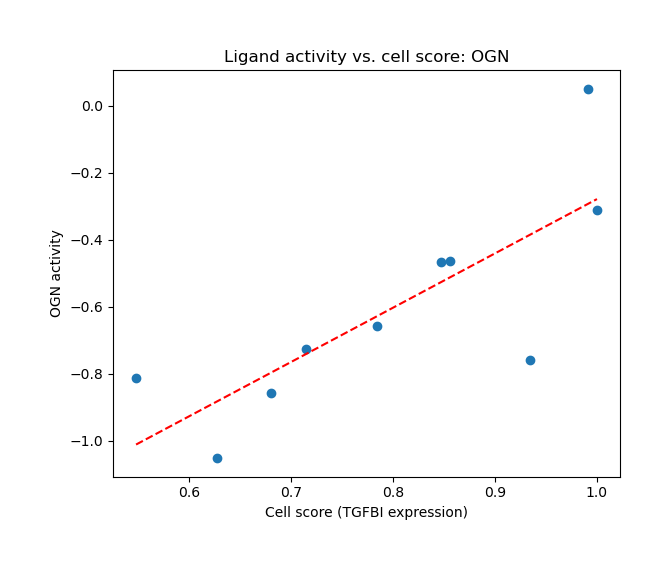

In [11]:
# Pick a top ligand to visualize
top_ligand = output_correlation_analysis.sort_values(
    "pearson_regression", ascending=False
)["ligand"].iloc[0]

merged = cell_scores_tbl.merge(normalized_ligand_activities, on="cell")

if top_ligand in merged.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(merged["score"], merged[top_ligand])
    # Add regression line
    z = np.polyfit(merged["score"], merged[top_ligand], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged["score"].min(), merged["score"].max(), 100)
    ax.plot(x_line, p(x_line), "r--")
    ax.set_xlabel("Cell score (TGFBI expression)")
    ax.set_ylabel(f"{top_ligand} activity")
    ax.set_title(f"Ligand activity vs. cell score: {top_ligand}")
    plt.tight_layout()
    plt.show()